#PIL(pillow)을 이용한 이미지 처리
-pip install Pillow

In [1]:
from PIL import Image

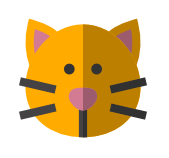

In [2]:
#이미지 불러오기
cat = Image.open("../Data/cat.png")
cat

In [3]:
#image layer 가져오기
cat.getbands()

('R', 'G', 'B')

#modes
-L for blck and white
-RGB for true color
-RGBA for true color with transparency mask
-YCbCr for color video(Rgb 아님) format

In [4]:
#mode 확인
cat.mode

'RGB'

In [5]:
#size
cat.size

(169, 158)

In [6]:
#file name
cat.filename

'../Data/cat.png'

In [7]:
#file format
cat.format

'PNG'

In [8]:
#convert to jpeg
cat.save("../Data/cat1.jpg")#png6k:분석=>jpg4k:빨리개발

#Image Resize

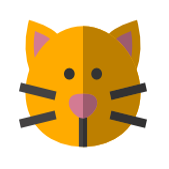

In [9]:
cat_resize=cat.resize((169,169))
cat_resize

In [10]:
cat_resize.size

(169, 169)

#Thumb nail 만들기
-가로와 세로의 크기를 반으로 줄인다.
-반으로 줄이면 실수가 발생할수 있어 truncate 한다.

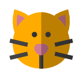

In [11]:
import math
size = (math.trunc(cat.size[0]/2), math.trunc(cat.size[1]/2))
size
catThumb=cat.copy()
catThumb.thumbnail(size)
catThumb

----
#이미지가 가운데에 있지 않으면 가운데로 옮겨야함
#Image Manipulation

#Image Crop(영상처리)

In [12]:
#이미지 크기
#왜튜플return:크기는 변하면 안되기 때문
print("전체크기:",cat.size)
print("가로크기:",cat.width)
print("세로크기:",cat.height)

전체크기: (169, 158)
가로크기: 169
세로크기: 158


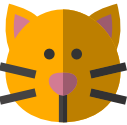

In [13]:
#####################
box = (20, 15, 147,140)#<<<<<<<<<<<<<<<<<왼쪽위가0
catCrop=cat.crop(box)#x좌표,y좌표,x크기,y크기
catCrop
#####################
#예측력 높이기 위해 crop

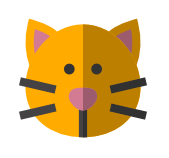

In [14]:
cat

#Image Rotate

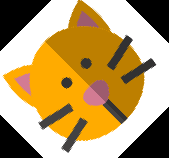

In [15]:
#####################
catRotate=cat.rotate(45)
catRotate
#################

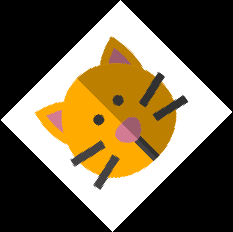

In [16]:
catRotate=cat.rotate(45,expand=True)
catRotate#해상도변함

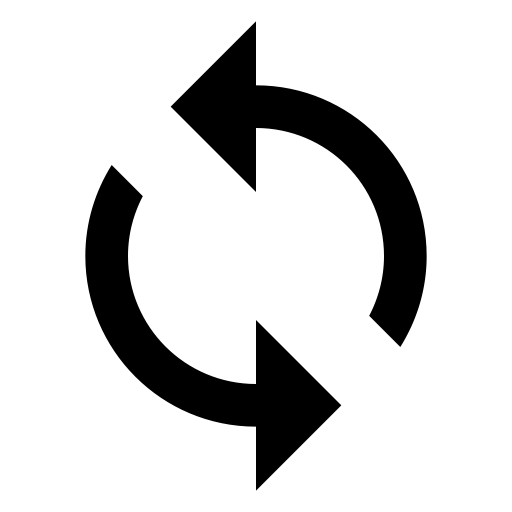

In [17]:
#png:a,알파값,투명도
record=Image.open("../Data/record.png")
record

In [18]:
#크기
record.size

(512, 512)

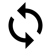

In [19]:
#이미지 크기가 cat 보다 커서 줄이자(1/10)

size = (math.trunc(record.size[0]/10), math.trunc(record.size[1]/10))
recordThumb=record.copy()
recordThumb.thumbnail(size)
recordThumb

In [20]:
recordThumb.size

(51, 51)

In [21]:
cat.size

(169, 158)

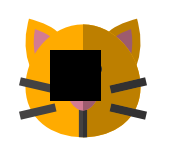

In [22]:
#cat 이미지 위에 recordThumb 배치(169,158)
position=(50,50)
catMerge=cat.copy()
catMerge.paste(recordThumb,position)
catMerge#cat:jpg+png=??

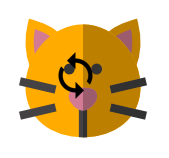

In [23]:
###########
position=(50,50)
catMerge=cat.copy()
catMerge.paste(recordThumb,position,recordThumb)
catMerge#알파값 빼기
#################

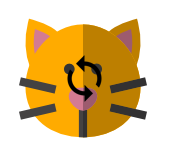

In [24]:
position=math.trunc((cat.width-recordThumb.width)/2),math.trunc((cat.height-recordThumb.height)/2)
catMerge=cat.copy()
catMerge.paste(recordThumb,position,recordThumb)
catMerge#알파값 빼기

################
Image Flip(좌우반전)
#################

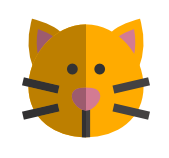

In [25]:
##################################
catFlip=cat.copy()#영상 생성시 매우 중요, 컬러가 좌우 반전됨
catFlip.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
################################

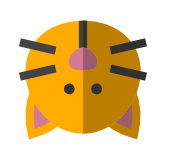

In [26]:
#Cnn 확률값?
catFlip.transpose(Image.Transpose.FLIP_TOP_BOTTOM)

#PIL image to Numpy array

In [27]:
import numpy as np

In [28]:
cat_array=np.array(cat)
cat_array

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

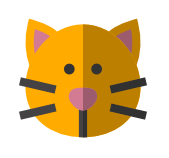

In [29]:
img=Image.fromarray(cat_array,"RGB")#컬러
img

In [30]:
#특정 pixel의 RGB Color
cat.getpixel((50,50))
#red+green=orange

(255, 171, 0)

#color transformation

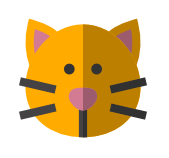

In [31]:
cat

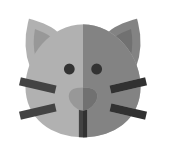

In [32]:
###################
#Gray Scale로 변환
cat.convert("L")# for blck and white
#################

#Image enhancement

In [33]:
from PIL import ImageEnhance

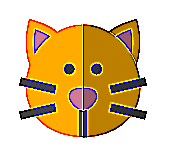

In [34]:
#image sharpness
enhancer= ImageEnhance.Sharpness(cat)
enhancer#cnn xframe?
enhancer.enhance(10.0)
enhancer.enhance(50.0)

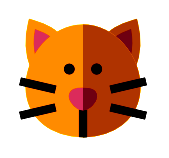

In [35]:
#Image contrast:밝은것 밝게 어두운것 어둡게
enhancer= ImageEnhance.Contrast(cat)
enhancer.enhance(2)

#Filters

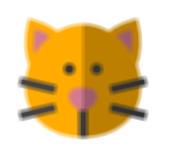

In [36]:
from PIL import ImageFilter
#Blur
cat.filter(ImageFilter.BLUR)#sharpness 반대

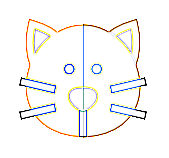

In [37]:
#Contour:형태 학습:CNN
cat.filter(ImageFilter.CONTOUR)

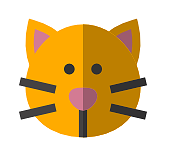

In [38]:
#Detail
cat.filter(ImageFilter.DETAIL)

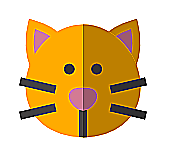

In [39]:
#Edge enhance:엣지 선명하게:주변중 가장 밝은 색?max?flip?
cat.filter(ImageFilter.EDGE_ENHANCE)

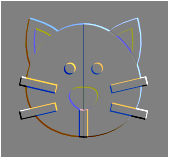

In [40]:
#EmBoSS
cat.filter(ImageFilter.EMBOSS)

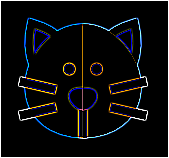

In [41]:
#Find Edges=maxflip?주변색 합쳐져 최대값으로 나타냄
cat.filter(ImageFilter.FIND_EDGES)

Animated GIF 분리하기

In [42]:
from PIL import ImageSequence

In [43]:
switch=Image.open("../Data/switch.gif")

In [44]:
frame_num=1
#for문
for frame in ImageSequence.Iterator(switch):#연속데이터 번호
    frame.save(f"../Data/switch/switch_{frame_num:02}.png")
    frame_num+=1
    if frame_num == 13:
        break

#Data Augmentation

#Image Shift

In [45]:
from PIL import ImageChops

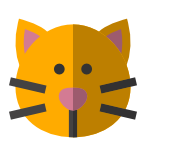

In [ ]:
#왼쪽으로 이동(배경으로 채워줌)
ImageChops.offset(cat,-10,0)

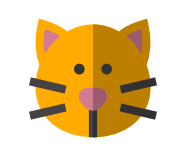

In [47]:
#오른쪽으로 이동(배경으로 채워줌)
ImageChops.offset(cat,10,0)

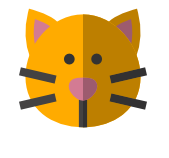

In [48]:
#위쪽으로 이동(배경으로 채워줌)
ImageChops.offset(cat,0,-10)

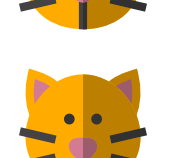

In [ ]:
#아래쪽으로 이동(배경으로 채워줌):잘림
ImageChops.offset(cat,0,50)#shift

#Noise Injection

In [50]:
#노이즈를 만들어 학습 시킴
from PIL import ImageDraw
import random

In [52]:
def add_noise(image1, noise_prob=0.01, color=(255,255,255)):#1%,하얀색
    image=image1.copy()
    width,height=image.size
    draw=ImageDraw.Draw(image)
    for x in range(width):
        for y in range(height):
            if random.random()<noise_prob:
             draw.point((x,y), fill=color)

    return image

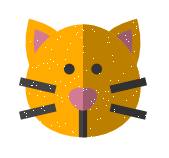

In [ ]:
catNoise=add_noise(cat)
catNoise#실행시 마다 노이즈 바뀜

---
#Rotation과 Flip을 이용한 이미지 데이터 증강


In [ ]:
#for문 하나더 추가해야함
#회전 데이터
counter=0
for angle in range(-15,15,1):#1:30 , 0.5:60
    counter+=1
    img2=cat.rotate(angle)
    img2.save(f"../Data/catImage/{counter:03}.png")

    #반전 데이터 추가(시프트,노이즈 등)
    counter+=1
    img3=img2.transpose(Image.FLIP_LEFT_RIGHT)
    img3.save(f"../Data/catImage/{counter:03}.png")
#홀수:회전/짝수:flip